In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv('loan_prediction.csv')

In [8]:
# Drop unique identifier not needed for prediction
df.drop(columns=['Loan_ID'], inplace=True)
print("Data Shape:", df.shape)

Data Shape: (614, 12)


In [10]:
# 1. Impute missing values
mode_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']
for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# 2. Clean 'Dependents' column ('3+' to integer 3)
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(int)

# 3. Domain Feature Engineering
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# 4. Encode Categorical Variables
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Encode Target Variable (Y -> 1, N -> 0)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [12]:
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize numerical features for distance/gradient-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
models = {
    "Logistic Regression": (LogisticRegression(random_state=42), True),
    "Decision Tree": (DecisionTreeClassifier(max_depth=4, random_state=42), False),
    "Random Forest": (RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), False)
}

results = []

for name, (clf, use_scaled) in models.items():
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test
    
    # Train
    clf.fit(X_tr, y_train)
    
    # Evaluate
    preds = clf.predict(X_te)
    probs = clf.predict_proba(X_te)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall": round(recall_score(y_test, preds), 4),
        "F1-Score": round(f1_score(y_test, preds), 4),
        "ROC-AUC": round(roc_auc_score(y_test, probs), 4)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8618     0.8400  0.9882    0.9081   0.8486
      Decision Tree    0.8618     0.8469  0.9765    0.9071   0.7957
      Random Forest    0.8618     0.8400  0.9882    0.9081   0.8362
  Gradient Boosting    0.8374     0.8495  0.9294    0.8876   0.7944


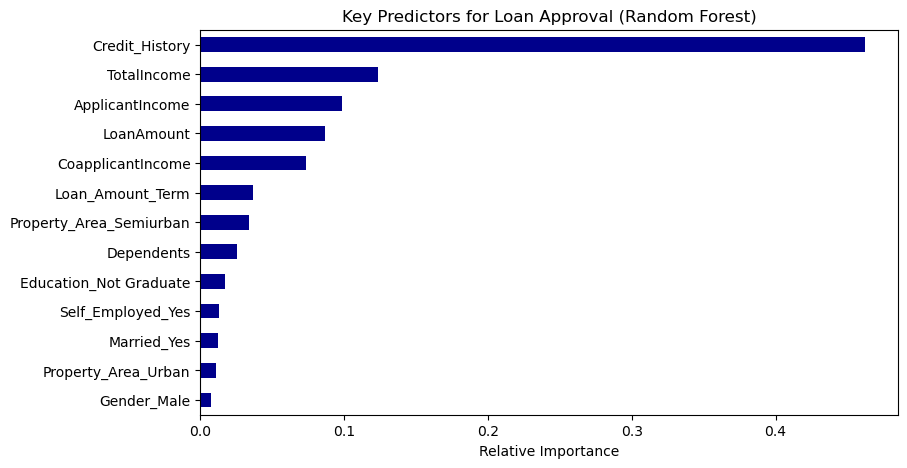

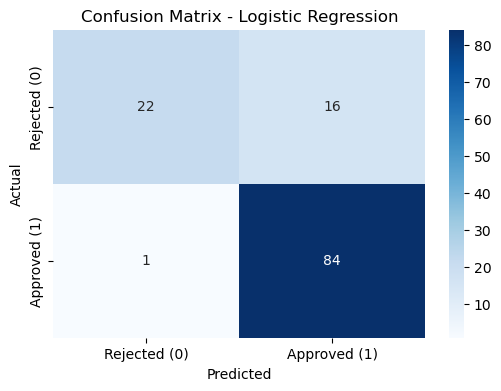

In [16]:
# 1. Feature Importance (Random Forest)
rf_model = models["Random Forest"][0]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='darkblue')
plt.title("Key Predictors for Loan Approval (Random Forest)")
plt.xlabel("Relative Importance")
plt.show()

# 2. Confusion Matrix for Logistic Regression
lr_model = models["Logistic Regression"][0]
cm = confusion_matrix(y_test, lr_model.predict(X_test_scaled))

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()